In [103]:
# data prep
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [104]:
dataset = pd.read_csv('skkrrr.csv')
dataset

C:\Users\USER\AppData\Local\Temp\ipykernel_17912\3072991573.py:1: DtypeWarning: Columns (12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv('skkrrr.csv')


,Date,Last Crawling,SKU Name,Product Name,Url Product,Seller,Merchant,Stock,Item Condition,Filter,Flag,Bottom Price,Original Price,Discount,Selling Price,Discrepancy,Sales Quantity,Sales Revenue
0,10/22/2022,10/22/2022,TL WR840N,TP-Link TL-WR840N 2 Antenna 300Mbps Wireless N...,https://tokopedia.com/ccplace/tp-link-tl-wr840...,ccplace shop,tokopedia,In Stock,baru,Above,Please Check,155000,231000,0,231000,0.014903,0,0
1,10/22/2022,10/22/2022,TL WR840N,Promo TP-LINK TL-WR840N Wireless Router 300Mbp...,https://tokopedia.com/gilsaashopp/promo-tp-lin...,gilsaa_shopp,tokopedia,In Stock,baru,Above,Please Check,155000,218800,0,218800,0.014116,0,0
2,10/22/2022,10/22/2022,TL WR840N,Tp-Link TL-WR840N 300Mbps Wireless N Speed Rou...,https://tokopedia.com/ccwinta/tp-link-tl-wr840...,ccwinta shop,tokopedia,In Stock,baru,Above,Please Check,155000,227000,0,227000,0.014645,0,0
3,10/22/2022,10/22/2022,TL WR840N,JARINGAN TP-LINK TL-WR 840N TL-WR840N 300MBps ...,https://tokopedia.com/belsa/jaringan-tp-link-t...,BELSA_SHOP,tokopedia,In Stock,baru,Above,Please Check,155000,263000,0,263000,0.016968,0,0
4,10/22/2022,10/22/2022,TL WR840N,TPLink TL-WR840N Router Wireless WiFi 300Mbps ...,https://tokopedia.com/ccwinta/tplink-tl-wr840n...,ccwinta shop,tokopedia,In Stock,baru,Above,Please Check,155000,236000,0,236000,0.015226,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32767,09/20/2022,09/20/2022,TL WR840N,KODE CVUSM02 TP-LINK TL-WR840N 300MBps Wireles...,https://tokopedia.com/cvunggulsidomukti/kode-c...,CV Unggul Sido Mukti,tokopedia,In Stock,baru,Above,Please Check,155000,244000,0,244000,0.015742,0,0
32768,09/20/2022,09/20/2022,TL WR840N,WIRELESS ROUTER TP-LINK TL-WR840N 300Mbps,https://tokopedia.com/carlton279/wireless-rout...,carlton279,tokopedia,In Stock,baru,Above,Please Check,155000,212000,0,212000,0.013677,0,0
32769,09/20/2022,09/20/2022,TL WR840N,TP-LINK TL-WR840N 300Mbps Wireless Router / Wi...,https://tokopedia.com/forgotenstore/tp-link-tl...,Forgoten Store,tokopedia,In Stock,baru,Above,Please Check,155000,271733,0,271733,0.017531,0,0
32770,09/20/2022,09/20/2022,TL WR840N,WIRELESS ROUTER TP-LINK TL-WR840N 300Mbps,https://tokopedia.com/sani1/wireless-router-tp...,Sani1_Shop,tokopedia,In Stock,baru,Above,Please Check,155000,210000,0,210000,0.013548,0,0


In [105]:
dataset = dataset[['Original Price', 'Bottom Price', 'Selling Price']].dropna()

In [106]:
dataset["Original Price"] = pd.to_numeric(dataset["Original Price"], errors="coerce")
dataset["Bottom Price"] = pd.to_numeric(dataset["Bottom Price"], errors="coerce")
dataset["Selling Price"] = pd.to_numeric(dataset["Selling Price"], errors="coerce")

In [107]:
dataset = dataset[(dataset['Original Price'] < 1_000_000) & (dataset['Selling Price'] < 1_000_000) & (dataset['Bottom Price'] < 1_000_000)]

In [108]:
print(dataset.info())
print("Jumlah data setelah cleaning:", len(dataset))
print(dataset.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 32685 entries, 0 to 32771
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Original Price  32685 non-null  float64
 1   Bottom Price    32685 non-null  int64  
 2   Selling Price   32685 non-null  int64  
dtypes: float64(1), int64(2)
memory usage: 1021.4 KB
None
Jumlah data setelah cleaning: 32685
       Original Price  Bottom Price  Selling Price
count    32685.000000       32685.0   32685.000000
mean    260702.337125      155000.0  260502.512651
std      79832.316181           0.0   79750.796679
min      25000.000000      155000.0   25000.000000
25%     214000.000000      155000.0  214000.000000
50%     242000.000000      155000.0  242000.000000
75%     286400.000000      155000.0  286000.000000
max     999999.000000      155000.0  999999.000000


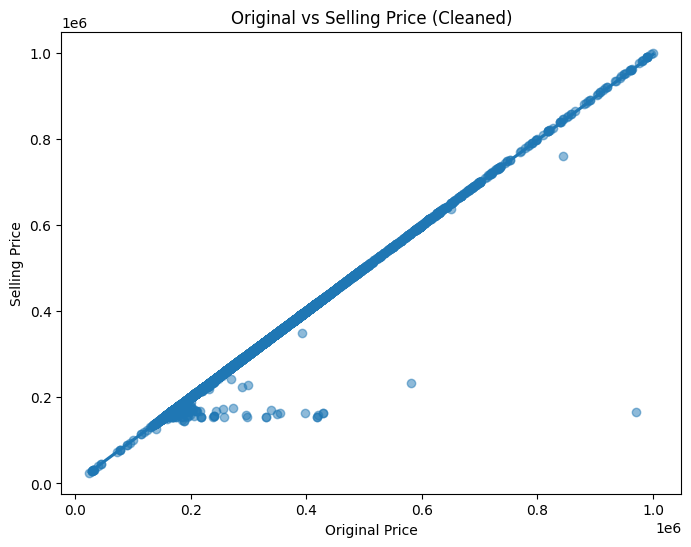

In [109]:
# eda
plt.figure(figsize=(8,6))
plt.scatter(dataset["Original Price"], dataset["Selling Price"], alpha=0.5)  # alpha untuk atasi overplotting
plt.xlabel("Original Price")
plt.ylabel("Selling Price")
plt.title("Original vs Selling Price (Cleaned)")
sns.regplot(x="Original Price", y="Selling Price", data=dataset, scatter=False)
plt.show()

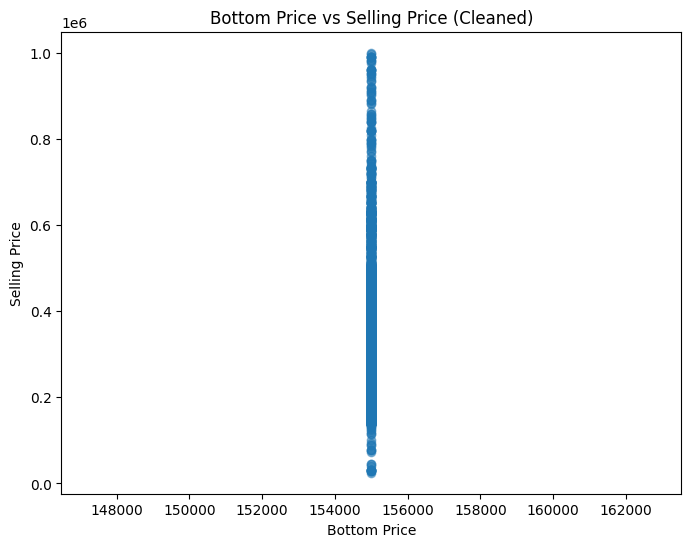

In [110]:
plt.figure(figsize=(8,6))
plt.scatter(dataset["Bottom Price"], dataset["Selling Price"], alpha=0.5)  # alpha untuk atasi overplotting
plt.xlabel("Bottom Price")
plt.ylabel("Selling Price")
plt.title("Bottom Price vs Selling Price (Cleaned)")
sns.regplot(x="Bottom Price", y="Selling Price", data=dataset, scatter=False)
plt.show()

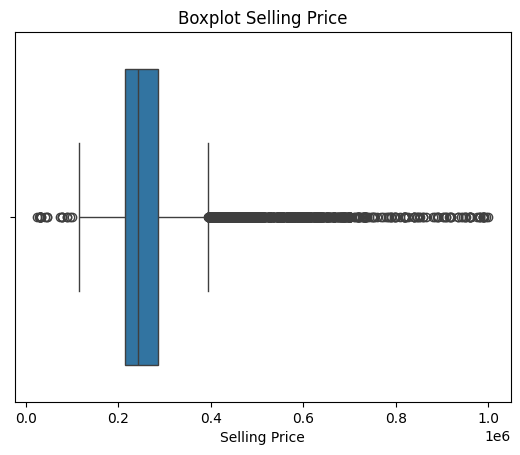

In [111]:
sns.boxplot(x=dataset['Selling Price'])
plt.title("Boxplot Selling Price")
plt.show()

In [112]:
Q1 = dataset['Selling Price'].quantile(0.25)
Q3 = dataset['Selling Price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = dataset[(dataset['Selling Price'] < lower) | (dataset['Selling Price'] > upper)]

print(outliers)
print("Jumlah outlier:", len(outliers))
print(outliers.head())

       Original Price  Bottom Price  Selling Price
28           818000.0        155000         818000
49           654000.0        155000         654000
51           818000.0        155000         818000
62           528000.0        155000         528000
75           496000.0        155000         496000
...               ...           ...            ...
32633        425000.0        155000         425000
32654        399000.0        155000         399000
32661        424000.0        155000         424000
32669        601000.0        155000         601000
32685        605000.0        155000         605000

[1506 rows x 3 columns]
Jumlah outlier: 1506
    Original Price  Bottom Price  Selling Price
28        818000.0        155000         818000
49        654000.0        155000         654000
51        818000.0        155000         818000
62        528000.0        155000         528000
75        496000.0        155000         496000


In [113]:
print("Contoh data outlier:")
print(outliers.head(10))

Contoh data outlier:
     Original Price  Bottom Price  Selling Price
28         818000.0        155000         818000
49         654000.0        155000         654000
51         818000.0        155000         818000
62         528000.0        155000         528000
75         496000.0        155000         496000
122        493000.0        155000         493000
223        486000.0        155000         486000
245        536000.0        155000         536000
264        652000.0        155000         652000
270        818000.0        155000         818000


In [114]:
# ambil data tanpa outlier
dataset_no_outliers = dataset[(dataset['Selling Price'] >= lower) & (dataset['Selling Price'] <= upper)]

print("Jumlah data awal:", len(dataset))
print("Jumlah setelah outlier dibuang:", len(dataset_no_outliers))

Jumlah data awal: 32685
Jumlah setelah outlier dibuang: 31179


In [115]:
X = dataset[['Original Price', 'Bottom Price']]
y = dataset['Selling Price']

In [116]:
# modeling
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [117]:
# nambah bias
X_bias = np.c_[np.ones(X.shape[0]), X]

In [118]:
theta, _, _, _ = np.linalg.lstsq(X_bias, y, rcond=None)

In [119]:
print("Koefisien regresi (theta):", theta)

Koefisien regresi (theta): [4.19769030e-08 9.95365137e-01 6.50641997e-03]


In [120]:
y_pred = X_bias @ theta

In [121]:
# evaluasi
X = dataset[['Original Price', 'Bottom Price']].values
y = dataset['Selling Price'].values

In [122]:
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - (ss_res / ss_tot)

In [123]:
print("R2 Score:", r2)

R2 Score: 0.9927782406142066


In [124]:
mse = np.mean((y - y_pred)**2)
mae = np.mean(np.abs(y - y_pred))

In [125]:
print("MSE:", mse)
print("MAE:",mae)

MSE: 45930353.443440594
MAE: 459.09678392054013


In [126]:
r = dataset['Original Price'].corr(dataset['Selling Price'])
print(f"Pearson r = {r:.3f}")

Pearson r = 0.996


In [127]:
r = dataset['Bottom Price'].corr(dataset['Selling Price'])
print(f"Pearson r = {r:.3f}")

Pearson r = nan


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:3063: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:3064: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [128]:
prediksi_dataset = pd.DataFrame({
    "Original Price": X[:,0],
    "Bottom Price": X[:,1],
    "Actual Selling Price": y,
    "Predicted Selling Price": y_pred
})

print(prediksi_dataset.head(10))

   Original Price  Bottom Price  Actual Selling Price  Predicted Selling Price
0        231000.0      155000.0                231000            230937.841784
1        218800.0      155000.0                218800            218794.387110
2        227000.0      155000.0                227000            226956.381235
3        263000.0      155000.0                263000            262789.526173
4        236000.0      155000.0                236000            235914.667470
5        236000.0      155000.0                236000            235914.667470
6        239000.0      155000.0                239000            238900.762881
7        267000.0      155000.0                267000            266770.986722
8        241500.0      155000.0                241500            241389.175724
9        231000.0      155000.0                231000            230937.841784


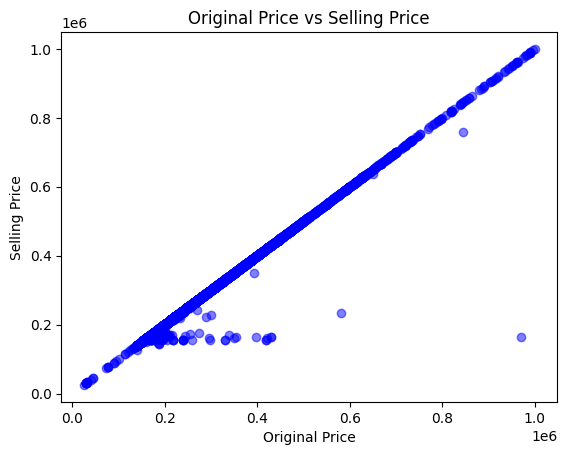

In [129]:
# visualisasi regresi cleaned
plt.scatter(X[:,0], y, color="blue", alpha=0.5, label="Original Price")
plt.xlabel("Original Price")
plt.ylabel("Selling Price")
plt.title("Original Price vs Selling Price")
plt.show()

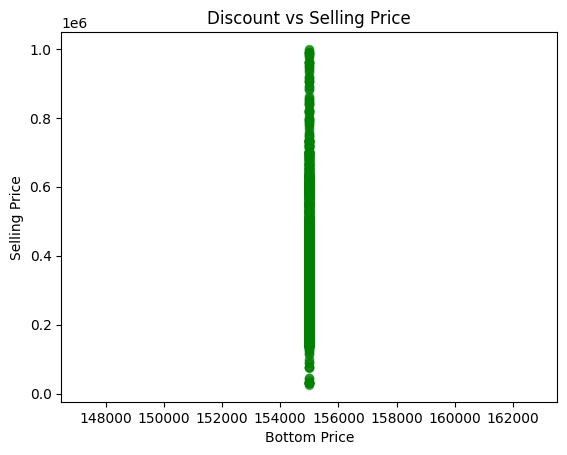

In [130]:
plt.scatter(X[:,1], y, color="green", alpha=0.5, label="Bottom Price")
plt.xlabel("Bottom Price")
plt.ylabel("Selling Price")
plt.title("Discount vs Selling Price")
plt.show()